# Generating embeddings using TorchGeo

## 1. Dataset organization

### Downloading the CropHarvest dataset

In [484]:
from torchgeo.datasets import CropHarvest

RANDOM_STATE = 1998
ROOT = "_data"
OUTPUT_FOLDER = "_results/"
WEIGHTS = 'dofa_base_patch16_224'

original_dataset = CropHarvest(root=ROOT, download=False)

In [408]:
# pandas dataframe containing label data for everything on CropHarvest
original_dataset._load_labels(ROOT).head(5)

,type,properties.harvest_date,properties.planting_date,properties.label,properties.classification_label,properties.index,properties.is_crop,properties.lat,properties.lon,properties.dataset,properties.collection_date,properties.export_end_date,properties.externally_contributed_dataset,properties.is_test,geometry.type,geometry.coordinates,geometry
0,Feature,None,None,None,None,0,1,10.712596,37.083128,ethiopia,2020-10-22T00:00:00,2021-02-01T00:00:00,False,False,Polygon,"[[[37.0825205254332, 10.712735028397], [37.083...",NaN
1,Feature,None,None,None,None,1,1,10.724197,37.087377,ethiopia,2020-10-22T00:00:00,2021-02-01T00:00:00,False,False,Polygon,"[[[37.0872134731101, 10.7239755790256], [37.08...",NaN
2,Feature,None,None,None,None,2,1,10.713894,37.085091,ethiopia,2020-10-22T00:00:00,2021-02-01T00:00:00,False,False,Polygon,"[[[37.0849835772546, 10.7137105808623], [37.08...",NaN
3,Feature,None,None,None,None,3,1,10.713338,37.090290,ethiopia,2020-10-22T00:00:00,2021-02-01T00:00:00,False,False,Polygon,"[[[37.0902073888884, 10.7132048338664], [37.09...",NaN
4,Feature,None,None,None,None,4,1,10.721858,37.083121,ethiopia,2020-10-22T00:00:00,2021-02-01T00:00:00,False,False,Polygon,"[[[37.0830703114103, 10.7215953100434], [37.08...",NaN


### Exploring the dataset

In [409]:
# under properties.dataset we can find the names of the "sub datasets" inside CropHarvest
original_dataset_counts = original_dataset.labels['properties.dataset'].value_counts()

#  all the subdataset inside the CropHarvest dataset and the number of its samples
print("Sub-datasets inside CropHarvest:")
print(original_dataset_counts)

Sub-datasets inside CropHarvest:
properties.dataset
geowiki-landcover-2017          35866
croplands                       14976
canada                           9088
ile-de-france                    6184
central-asia                     5302
rwanda-ceo                       3600
reunion-france                   2776
kenya-non-crop                   2704
germany                          2550
martinique-france                2421
tanzania-ceo                     2400
mali-helmets-labelling-crops     1506
togo                             1276
lem-brazil                        860
ethiopia                          830
tanzania-rice-ecaas               800
sudan                             422
tanzania                          392
kenya                             319
togo-eval                         306
uganda                            233
mali                              148
mali-non-crop                     142
zimbabwe                           49
brazil-non-crop                    3

In [411]:
# group by the sub dataset name and look at the 'properties.label' column, which contains the crop type names
# if it is binary it will be None
# if it is multiclass it will have the crop type names

original_dataset_class_search = original_dataset.labels.groupby('properties.dataset')['properties.label'].unique()

binary = []
multiclass = []

for sub_dataset, labels in original_dataset_class_search.items():
    labels = [l for l in labels if l is not None and not (isinstance(l, float))]

    if len(labels) > 0:
        multiclass.append((sub_dataset, labels))
    else:
        binary.append(sub_dataset)

print("Binary sub-datasets:")
for i in binary:
    print(i)

print("\nMulticlass sub-datasets:")
for j in multiclass:
    print(j)

Binary sub-datasets:
brazil-non-crop
ethiopia
geowiki-landcover-2017
kenya-non-crop
mali-non-crop
rwanda-ceo
sudan
tanzania-ceo
togo
togo-eval

Multiclass sub-datasets:
('canada', ['wetland', 'abandoned (overgrown)', 'urban', 'shrubland', 'mixed forage', 'pasture (undiff)', 'sod', 'cereals (undiff)', 'barley (undiff)', 'corn', 'timothy', 'alfalfa', 'spring wheat', 'soybeans', 'forest', 'nursery', 'winter barley', 'canola/rapeseed', 'winter wheat', 'unimproved pasture', 'christmas trees', 'greenhouse', 'winter rye', 'pasture/forage', 'red clover', 'abandoned (shrubs)', 'other', 'fallow', 'native grassland', 'barren', 'water', 'oats', 'coniferous', 'white clover', 'broadleaf', 'clover (undiff)', 'sunflowers', 'greenfeed (mixed)', 'beans (undiff)', 'melon', 'apples', 'vegetables (undiff)', 'raspberry', 'fruits (berry & annual)', 'strawberry', 'onions', 'potatoes', 'broccoli', 'cauliflower', 'peas (undiff)', 'field peas', 'sugarbeets', 'ginseng', 'rye (undiff)', 'cherries', 'cucumber', 'to

## 2. *geowiki-landcover-2017* data exploration

### Isolate *geowiki-landcover-2017* sub dataset


We want to work with an isolated sub-set, binary, and preferably with lots of samples. For that reason it is wise to choose *geowiki-landcover-2017*
- **Sub dataset name:** *geowiki-landcover-2017*
- **Sample Count:** 35866 points
- **Format:** pixel-level time series

In [515]:
from torch.utils.data import Subset

# finding all the entries on original_dataset that has properties.dataset equal to 'geowiki-landcover-2017'
DATASET_NAME = 'geowiki-landcover-2017'
geowiki_indices = original_dataset.labels.index[original_dataset.labels['properties.dataset'] == DATASET_NAME].tolist()

# create the isolated dataset
geowiki_dataset = Subset(original_dataset, geowiki_indices)

print(f"Original dataset size: {len(original_dataset)}")
print(f"Isolated dataset size: {len(geowiki_dataset)}")
print(f"Geowiki indexes taken from the original dataset: {geowiki_indices}")

Original dataset size: 70213
Isolated dataset size: 35866
Geowiki indexes taken from the original dataset: [3694, 3695, 3696, 3697, 3698, 3699, 3700, 3701, 3702, 3703, 3704, 3705, 3706, 3707, 3708, 3709, 3710, 3711, 3712, 3713, 3714, 3715, 3716, 3717, 3718, 3719, 3720, 3721, 3722, 3723, 3724, 3725, 3726, 3727, 3728, 3729, 3730, 3731, 3732, 3733, 3734, 3735, 3736, 3737, 3738, 3739, 3740, 3741, 3742, 3743, 3744, 3745, 3746, 3747, 3748, 3749, 3750, 3751, 3752, 3753, 3754, 3755, 3756, 3757, 3758, 3759, 3760, 3761, 3762, 3763, 3764, 3765, 3766, 3767, 3768, 3769, 3770, 3771, 3772, 3773, 3774, 3775, 3776, 3777, 3778, 3779, 3780, 3781, 3782, 3783, 3784, 3785, 3786, 3787, 3788, 3789, 3790, 3791, 3792, 3793, 3794, 3795, 3796, 3797, 3798, 3799, 3800, 3801, 3802, 3803, 3804, 3805, 3806, 3807, 3808, 3809, 3810, 3811, 3812, 3813, 3814, 3815, 3816, 3817, 3818, 3819, 3820, 3821, 3822, 3823, 3824, 3825, 3826, 3827, 3828, 3829, 3830, 3831, 3832, 3833, 3834, 3835, 3836, 3837, 3838, 3839, 3840, 3841, 3842

### Data structure

Each data point represents a single geographic location over a full calendar year. Each sample is provided as a $12 \times 18$ tensor:
- Rows (12): Represent the 12 months of the year (temporal dimension)
- Columns (18): Represent the spectral and environmental bands (feature dimension)

The data combines multiple sensors and environmental variables:

| Band Index | Feature Category | Description |
| :--- | :--- | :--- |
| **0 - 12** | **Sentinel-2 (Optical)** | Multi-spectral bands including RGB, NIR, and Red-Edge |
| **13 - 14** | **Sentinel-1 (Radar)** | VV and VH polarizations (crucial for cloud-penetrating growth monitoring) |
| **15** | **ERA5 (Temp)** | 2-meter temperature data (average monthly) |
| **16** | **ERA5 (Precip)** | Total monthly precipitation |
| **17** | **SRTM (Elevation)** | Digital Elevation Model (Static value repeated across time steps) |

In [516]:
original_dataset.all_bands

('VV',
 'VH',
 'B2',
 'B3',
 'B4',
 'B5',
 'B6',
 'B7',
 'B8',
 'B8A',
 'B9',
 'B11',
 'B12',
 'temperature_2m',
 'total_precipitation',
 'elevation',
 'slope',
 'NDVI')

In [517]:
geowiki_dataset[7].keys()

dict_keys(['array', 'label'])

In [518]:
geowiki_dataset.__getitem__(45)['array'].shape

torch.Size([12, 18])

In [519]:
geowiki_dataset.__getitem__(45)['label']

tensor(62)

### Turning *geowiki-landcover-2017* into a binary dataset

But we can see that, after a careful look that not only the dataset label are not bianry but also they don't match with the classification labels `properties.is_crop`shown in the beginning. 

In [571]:
def investigation(subset, original, geowiki_indices, num_samples, y_array=None):
    header = f"{'Idx':<5} | {'Origianl Idx':<5} |{'My tensor':<8} | {'Metadata is_crop':<10} | {'embedding':<8} | {'Status'}"
    print(header)
    print("-" * 75)

    for i in range(num_samples):
        # label from my dataset
        label_my_dataset = int(subset[i]['label'])
        
        # original label
        idx_original = geowiki_indices[i]
        is_crop_meta = int(original.labels['properties.is_crop'].iloc[idx_original])
        
        # label from embedding
        y_val = y_array[i] if y_array is not None else "N/A"
        
        if label_my_dataset == is_crop_meta:
            status = "ok"
        else:
            status = "!!!MISMATCH!!!"

        if y_array is not None and y_val != is_crop_meta:
            status = "embedding mismatching"


        print(f"{i:<5} | {idx_original:<12} |{label_my_dataset:<9} | {is_crop_meta:<16} | {y_val:<9} | {status}")
    
    return

In [572]:
investigation(geowiki_dataset, original_dataset, geowiki_indices, 20)

Idx   | Origianl Idx |My tensor | Metadata is_crop | embedding | Status
---------------------------------------------------------------------------
0     | 3694         |0         | 0                | N/A       | ok
1     | 3695         |1         | 1                | N/A       | ok
2     | 3696         |0         | 0                | N/A       | ok
3     | 3697         |1         | 1                | N/A       | ok
4     | 3698         |1         | 0                | N/A       | !!!MISMATCH!!!
5     | 3699         |1         | 1                | N/A       | ok
6     | 3700         |1         | 0                | N/A       | !!!MISMATCH!!!
7     | 3701         |0         | 1                | N/A       | !!!MISMATCH!!!
8     | 3702         |1         | 0                | N/A       | !!!MISMATCH!!!
9     | 3703         |1         | 0                | N/A       | !!!MISMATCH!!!
10    | 3704         |1         | 1                | N/A       | ok
11    | 3705         |14        | 1         

For this reason, we need to change the tensor label in each sample to match the metadata `properties.is_crop`.

In [445]:
import torch

class BinaryDatasetWrapper(torch.utils.data.Dataset):
    def __init__(self, subset, original_dataset, bridge_indices):
        self.subset = subset
        self.original_labels = original_dataset.labels['properties.is_crop']
        self.bridge_indices = bridge_indices

    def __getitem__(self, index):
        sample = self.subset[index]
        
        orig_idx = self.bridge_indices[index]
        
        correct_label_value = int(self.original_labels.iloc[orig_idx])
        
        sample['label'] = torch.tensor(correct_label_value)
        return sample

    def __len__(self):
        return len(self.subset)

In [452]:
dataset = BinaryDatasetWrapper(geowiki_dataset, original_dataset, geowiki_indices)

In [466]:
dataset[0]['array'] == original_dataset.__getitem__(geowiki_indices[0])['array']

tensor([[True, True, True, True, True, True, True, True, True, True, True, True,
         True, True, True, True, True, True],
        [True, True, True, True, True, True, True, True, True, True, True, True,
         True, True, True, True, True, True],
        [True, True, True, True, True, True, True, True, True, True, True, True,
         True, True, True, True, True, True],
        [True, True, True, True, True, True, True, True, True, True, True, True,
         True, True, True, True, True, True],
        [True, True, True, True, True, True, True, True, True, True, True, True,
         True, True, True, True, True, True],
        [True, True, True, True, True, True, True, True, True, True, True, True,
         True, True, True, True, True, True],
        [True, True, True, True, True, True, True, True, True, True, True, True,
         True, True, True, True, True, True],
        [True, True, True, True, True, True, True, True, True, True, True, True,
         True, True, True, Tru

In [573]:
investigation(dataset, original_dataset, geowiki_indices, 20)

Idx   | Origianl Idx |My tensor | Metadata is_crop | embedding | Status
---------------------------------------------------------------------------
0     | 3694         |0         | 0                | N/A       | ok
1     | 3695         |1         | 1                | N/A       | ok
2     | 3696         |0         | 0                | N/A       | ok
3     | 3697         |1         | 1                | N/A       | ok
4     | 3698         |0         | 0                | N/A       | ok
5     | 3699         |1         | 1                | N/A       | ok
6     | 3700         |0         | 0                | N/A       | ok
7     | 3701         |1         | 1                | N/A       | ok
8     | 3702         |0         | 0                | N/A       | ok
9     | 3703         |0         | 0                | N/A       | ok
10    | 3704         |1         | 1                | N/A       | ok
11    | 3705         |1         | 1                | N/A       | ok
12    | 3706         |0         | 0 

### Data visualization

In [631]:
sample = dataset[2]
sample['label']

tensor(0)

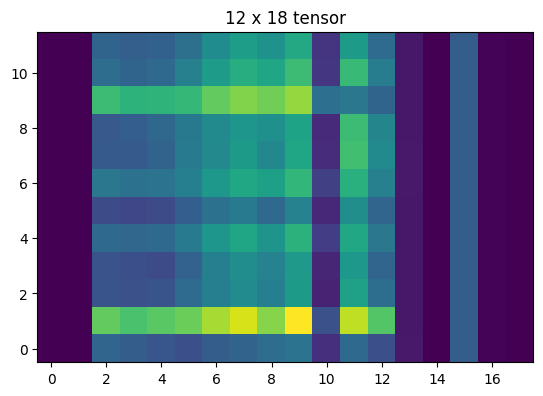

In [632]:
import matplotlib.pyplot as plt

# the actual tensor
plt.imshow(sample['array'], origin='lower')
plt.title("12 x 18 tensor")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.33066666666666666..1.1966666666666668].


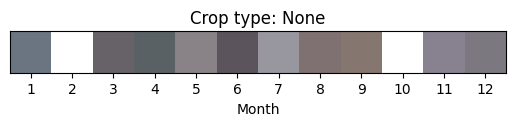

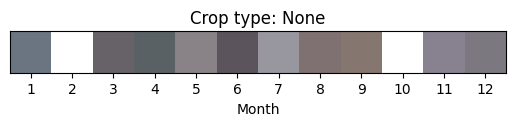

In [633]:
# it shows two plots because it is prepared to plot ground-truth and 
# it combines the rgb channels into a single pixel 
original_dataset.plot(sample)

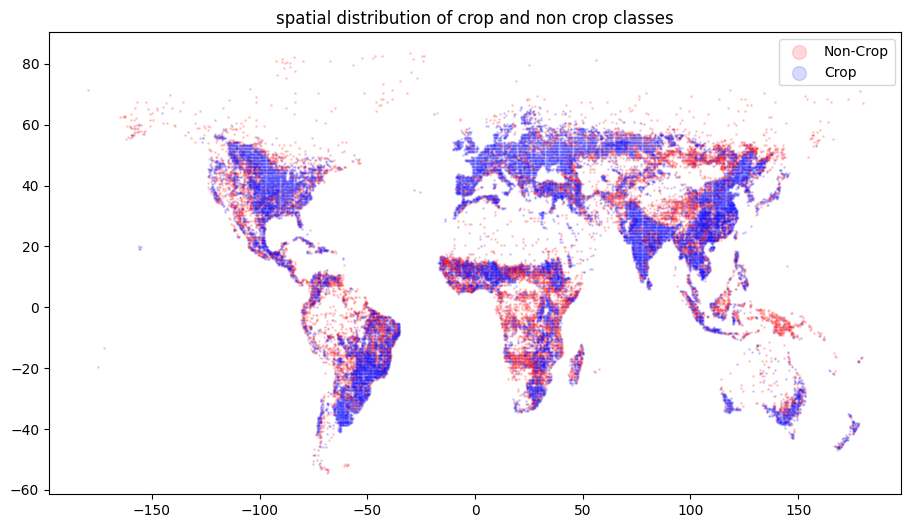

In [459]:
plt.figure(figsize=(11, 6))

geowiki_metadata = original_dataset.labels.iloc[geowiki_indices]

for is_crop, color, label in [(0, 'red', 'Non-Crop'), (1, 'blue', 'Crop')]:
    mask = geowiki_metadata['properties.is_crop'] == is_crop
    subset = geowiki_metadata[mask]
    plt.scatter(subset['properties.lon'], subset['properties.lat'], s=1, alpha=0.15, c=color, label=label)

plt.legend(markerscale=10)
plt.title("spatial distribution of crop and non crop classes")
plt.show()

## 3. Creating the embeddings model

### DOFA model

Instead of trying to retrain the whole DOFA model (which is huge and requires a lot of GPU memory), we will use DOFA as a "frozen" backbone to generate embeddings and train a simple, fast classifier on top.

In [473]:
import lightning as L
from torch.utils.data import DataLoader

class GeoWikiDataModule(L.LightningDataModule):
    def __init__(self, data, batch_size: int = 32, num_workers: int = 0):
        super().__init__()
        self.data = data
        self.batch_size = batch_size
        self.num_workers = num_workers

    def dataloader(self):
        return DataLoader(
            self.data, 
            batch_size=self.batch_size, 
            shuffle=False, 
            num_workers=self.num_workers
        )

In [479]:
# loading data
data_module = GeoWikiDataModule(dataset, batch_size=16, num_workers=0)
data_loader = data_module.dataloader()

In [480]:
# define device to use, cuda, cpu or mps (our case with mac)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps") # for mac users
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


In [485]:
from torchgeo.models import DOFABase16_Weights, get_model

model = get_model(WEIGHTS, weights=DOFABase16_Weights.DOFA_MAE)
model = model.eval()

In [486]:
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm

def embeddings_dofa(model, dataloader, device):
    model.eval()
    model.to(device)
    x_all, y_all = [] , []
    
    wavelengths = [60.0, 60.0, 490.0, 560.0, 665.0, 842.0, 1610.0, 2190.0, 
                   865.0, 705.0, 740.0, 783.0, 0.0, 0.0, 0.0, 0.0, 0.0, 490.0]

    for batch in tqdm(dataloader):
        x = batch['array'].to(torch.float32).to(device) 
        y = batch['label']

        # why doing this?!
        x = x.permute(0, 2, 1) 
        # and why doing this?!
        x = x.unsqueeze(-1)
        # also why doing this?!
        x = F.pad(x, (0, 15, 0, 4)) 

        with torch.inference_mode():
            features = model.forward_features(x, wavelengths=wavelengths)
            
            # why doing this?!
            if features.ndim == 3:
                # why doing this?!
                embeddings = features.mean(dim=1) 
            else:
                embeddings = features

        x_all.append(embeddings.cpu().numpy())
        y_all.append(y.numpy())

    return np.concatenate(x_all, axis=0), np.concatenate(y_all, axis=0)

In [487]:
# ensure that is running on mps or chosen device
model = model.to(device) 

print("Extracting embeddings...")
x, y = embeddings_dofa(model, data_loader, device)

print(f"Done! Created {x.shape[0]} vectors of size {x.shape[1]}")

Extracting embeddings...


100%|██████████| 2242/2242 [44:49<00:00,  1.20s/it]  

Done! Created 35866 vectors of size 768


In [488]:
# save the embeddings
np.save(f'{OUTPUT_FOLDER}x_dofa-{WEIGHTS}.npy', x)
np.save(f'{OUTPUT_FOLDER}y_dofa-{WEIGHTS}.npy', y)

print("Files saved successfully!")

Files saved successfully!


### Sanity check

In [489]:
# load the embeddings in case you dont want to run the model again
x = np.load(f'{OUTPUT_FOLDER}x_dofa-{WEIGHTS}.npy')
y = np.load(f'{OUTPUT_FOLDER}y_dofa-{WEIGHTS}.npy')

print("Files loaded successfully!")

Files loaded successfully!


In [574]:
investigation(dataset, original_dataset, geowiki_indices, 20, y)

Idx   | Origianl Idx |My tensor | Metadata is_crop | embedding | Status
---------------------------------------------------------------------------
0     | 3694         |0         | 0                | 0         | ok
1     | 3695         |1         | 1                | 1         | ok
2     | 3696         |0         | 0                | 0         | ok
3     | 3697         |1         | 1                | 1         | ok
4     | 3698         |0         | 0                | 0         | ok
5     | 3699         |1         | 1                | 1         | ok
6     | 3700         |0         | 0                | 0         | ok
7     | 3701         |1         | 1                | 1         | ok
8     | 3702         |0         | 0                | 0         | ok
9     | 3703         |0         | 0                | 0         | ok
10    | 3704         |1         | 1                | 1         | ok
11    | 3705         |1         | 1                | 1         | ok
12    | 3706         |0         | 0 

## Analysing the results

### Extracting lat and long 

Because the metadata will be lost after the train/test split (we'll lose the original indexes), it is necessary to save, at least, the latitude and longitude, following the same index order that the *geowiki-landcover-2017* dataset has.

In [575]:
import pandas as pd

def extract_coords(original_dataset, geowiki_indices):
    metadata_records = []
    raw_labels_df = original_dataset.labels 
    
    for i in range(len(geowiki_indices)):
        orig_idx = geowiki_indices[i]
        
        row = raw_labels_df.iloc[orig_idx]
        
        metadata_records.append({
            'subset_index': i,
            'original_index': orig_idx,
            'lat': row['properties.lat'],
            'lon': row['properties.lon'],
            'label': int(row['properties.is_crop']) # The verified label
        })
    
    return pd.DataFrame(metadata_records)

In [576]:
df_coords = extract_coords(original_dataset, geowiki_indices)
df_coords.head(20)

,subset_index,original_index,lat,lon,label
0,0,3694,-16.547619,46.25,0
1,1,3695,-18.547619,48.25,1
2,2,3696,-21.547619,44.25,0
3,3,3697,-17.547619,45.25,1
4,4,3698,-21.547619,46.25,0
5,5,3699,-25.547619,45.25,1
6,6,3700,-17.547619,47.25,0
7,7,3701,-18.547619,47.25,1
8,8,3702,-22.547619,45.25,0
9,9,3703,-22.547619,46.25,0


### Train/test split

In [578]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test, meta_train, meta_test = train_test_split(
    x, 
    y, 
    df_coords,
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

In [619]:
def check_balance(data, name="Dataset"):
    print(f"\n--- Class Balance: {name} ---")
    
    if isinstance(data, (np.ndarray, torch.Tensor)):
        values = data.flatten()
        if torch.is_tensor(values):
            values = values.cpu().numpy()
        unique, counts = np.unique(values, return_counts=True)
        stats = dict(zip(unique, counts))
        total = len(values)

    elif isinstance(data, (pd.DataFrame, pd.Series)):
        if isinstance(data, pd.DataFrame):
            stats = data['label'].value_counts().to_dict()
        else:
            stats = data.value_counts().to_dict()
        total = len(data)

    else:
        total = len(data)
        labels = []
        check_limit = total
        for i in range(check_limit):
            labels.append(int(data[i]['label']))
        unique, counts = np.unique(labels, return_counts=True)
        stats = dict(zip(unique, counts))
        if total > check_limit:
            print(f"(Note: Stats based on first {check_limit} samples)")

    for cls, count in stats.items():
        percentage = (count / sum(stats.values())) * 100
        label_name = "Crop (1)" if cls == 1 else "Non-Crop (0)"
        print(f"  {label_name:<12}: {count:>5} ({percentage:>5.1f}%)")
    
    print(f"  Total Samples: {total}")
    return stats

In [620]:
check_balance(dataset)


--- Class Balance: Dataset ---
  Non-Crop (0): 15764 ( 44.0%)
  Crop (1)    : 20102 ( 56.0%)
  Total Samples: 35866


{np.int64(0): np.int64(15764), np.int64(1): np.int64(20102)}

### Simple classifier

antes era 0.801

In [603]:
# verify with random forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# training
rf = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(x_train, y_train)

# predicting
y_pred = rf.predict(x_test)

# evaluating
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(classification_report(y_test, y_pred))

Random Forest Accuracy: 0.547
              precision    recall  f1-score   support

           0       0.47      0.28      0.35      3153
           1       0.57      0.75      0.65      4021

    accuracy                           0.55      7174
   macro avg       0.52      0.52      0.50      7174
weighted avg       0.53      0.55      0.52      7174



In [602]:
np.bincount(y_train)

array([12611, 16081])

### Embeddings visualization

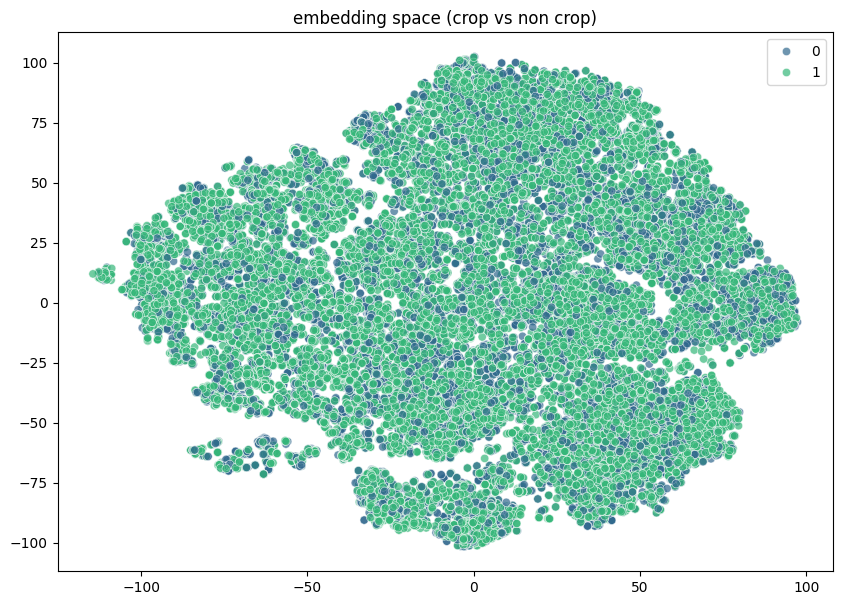

In [504]:
from sklearn.manifold import TSNE
import seaborn as sns

tsne = TSNE(n_components=2, random_state=RANDOM_STATE)
x_2d = tsne.fit_transform(x)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=x_2d[:,0], y=x_2d[:,1], hue=y, palette='viridis', alpha=0.7)
plt.title("embedding space (crop vs non crop)")
plt.show()

### Spatial correlation of the embeddings

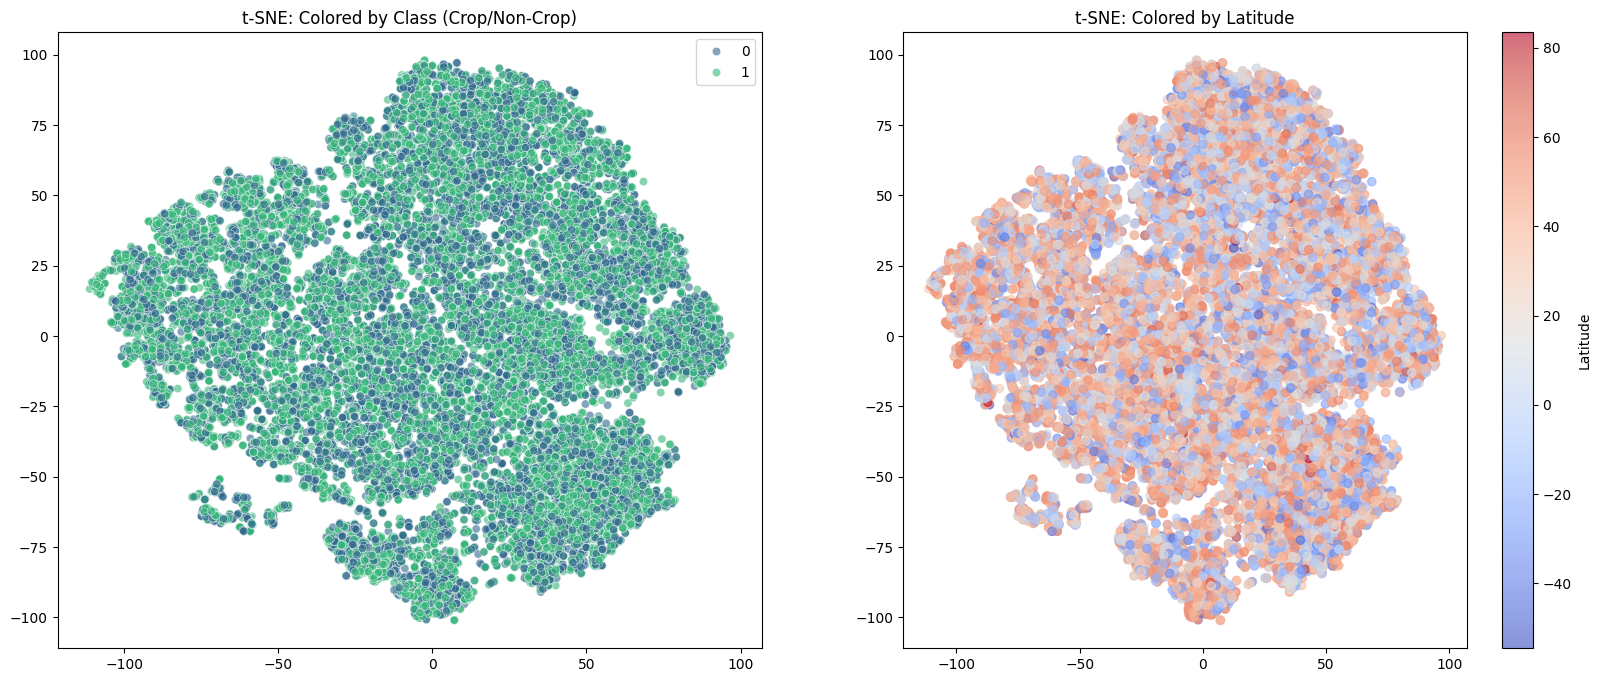

In [635]:
tsne = TSNE(n_components=2, random_state=42)
x_2d = tsne.fit_transform(x_train)

# 2. Plot side-by-side: One for Class, one for Geography
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot A: The Original (Crop vs Non-Crop)
sns.scatterplot(x=x_2d[:,0], y=x_2d[:,1], hue=y_train, palette='viridis', alpha=0.6, ax=ax1)
ax1.set_title("t-SNE: Colored by Class (Crop/Non-Crop)")

# Plot B: Colored by Latitude (using your meta_test or df_coords)
# Replace 'meta_test' with your master dataframe
scatter = ax2.scatter(x_2d[:,0], x_2d[:,1], c=meta_train['lat'], cmap='coolwarm', alpha=0.6)
fig.colorbar(scatter, ax=ax2, label='Latitude')
ax2.set_title("t-SNE: Colored by Latitude")

plt.show()

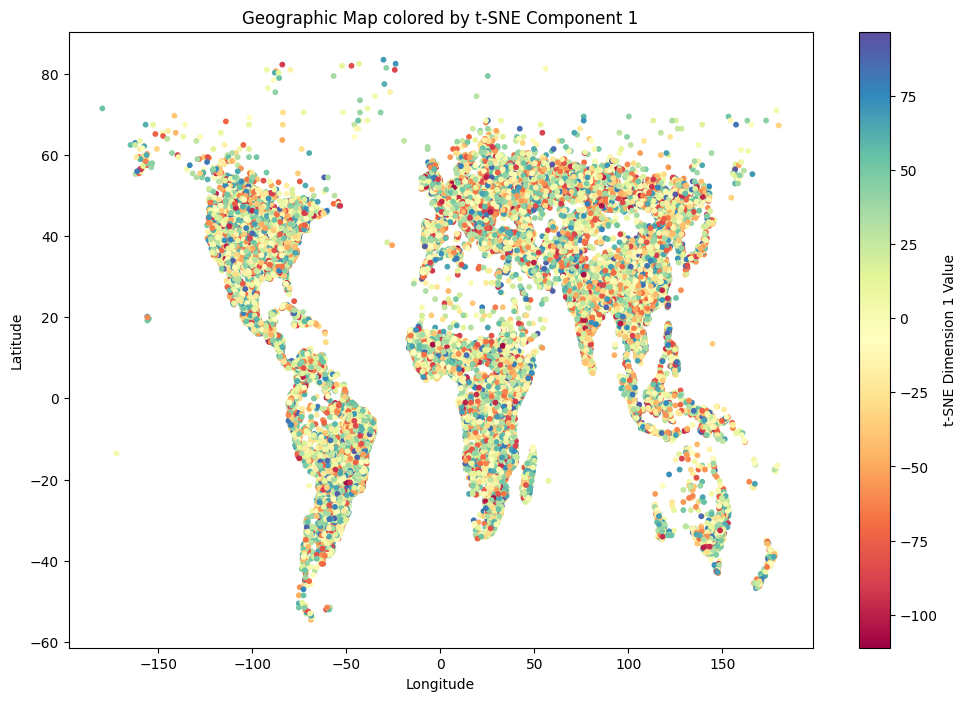

In [636]:
plt.figure(figsize=(12, 8))

# Here we plot actual Lat/Long but color by the t-SNE position
# We use x_2d[:,0] (the first t-SNE dimension) as the color
plt.scatter(meta_train['lon'], meta_train['lat'], c=x_2d[:,0], cmap='Spectral', s=10)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Map colored by t-SNE Component 1")
plt.colorbar(label="t-SNE Dimension 1 Value")
plt.show()